In [9]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.config import PROCESSED_DATA_PATH


In [ ]:

if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)
else:
    print("Файл не найден! Убедись, что путь указан верно.")

df.head(3)

,name,schedule,alternate_url,published_at,salary_from,salary_to,salary_currency,city,company,exp_level,requirement,responsibility,salary_avg
0,Backend-разработчик,"{'id': 'fullDay', 'name': 'Полный день'}",https://hh.ru/vacancy/131964448,2026-04-08T17:52:32+0300,100000.0,NaN,RUR,Москва,Айтисокет,Нет опыта,Базовые знания одного из языков программирован...,Создание и поддержка API. Работа с базами данн...,100000.0
1,Младший тестировщик ПО / Junior QA engineer,"{'id': 'fullDay', 'name': 'Полный день'}",https://hh.ru/vacancy/131988637,2026-04-09T13:15:01+0300,60000.0,80000.0,RUR,Москва,ИнтернетУрок,Нет опыта,Законченные курсы по тестированию. Умение анал...,...подходом Shift-left testing. Разработка тес...,70000.0
2,Аналитик данных (SQL),"{'id': 'fullDay', 'name': 'Полный день'}",https://hh.ru/vacancy/130971766,2026-04-02T12:07:13+0300,70000.0,80000.0,RUR,Москва,Чеки из Аптеки,Нет опыта,Способны аргументированно отстаивать собственн...,Ad-hock запросы поступающие от подразделений к...,75000.0


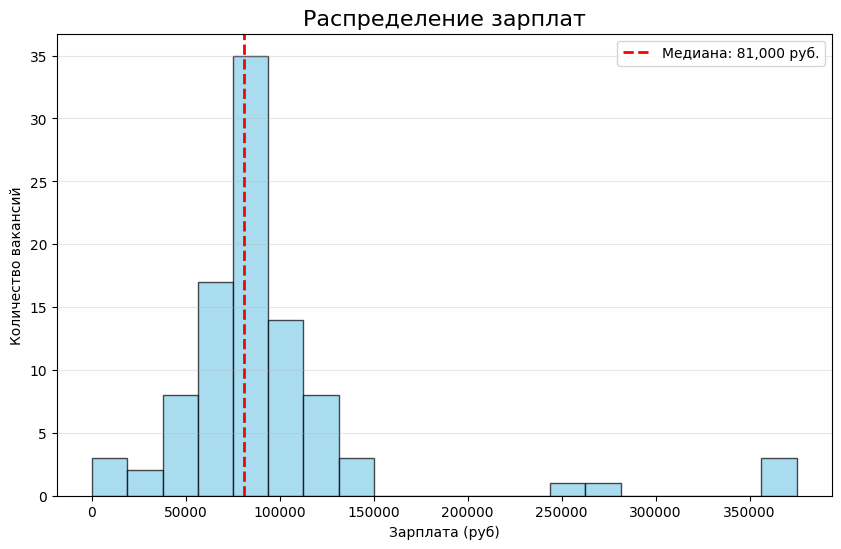

In [11]:
salary_data = df['salary_avg'].dropna()

median_salary = salary_data.median()

plt.figure(figsize=(10, 6))
plt.hist(salary_data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(median_salary, color='red', linestyle='dashed', linewidth=2, label=f'Медиана: {median_salary:,.0f} руб.')

plt.title('Распределение зарплат', fontsize=16)
plt.xlabel('Зарплата (руб)')
plt.ylabel('Количество вакансий')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

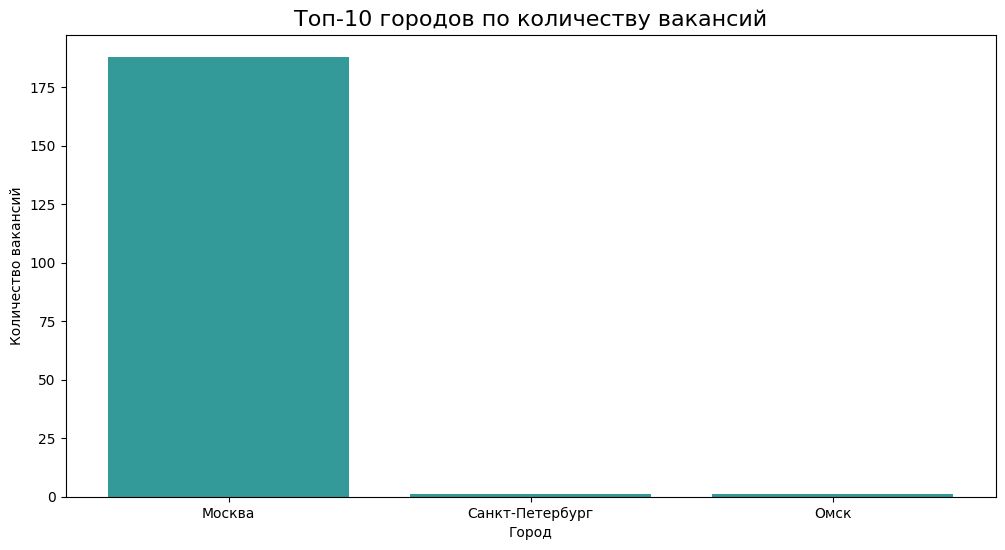

In [20]:
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(city_counts.index, city_counts.values, color='teal', alpha=0.8)

plt.title('Топ-10 городов по количеству вакансий', fontsize=16)
plt.xlabel('Город')
plt.ylabel('Количество вакансий')
plt.show()

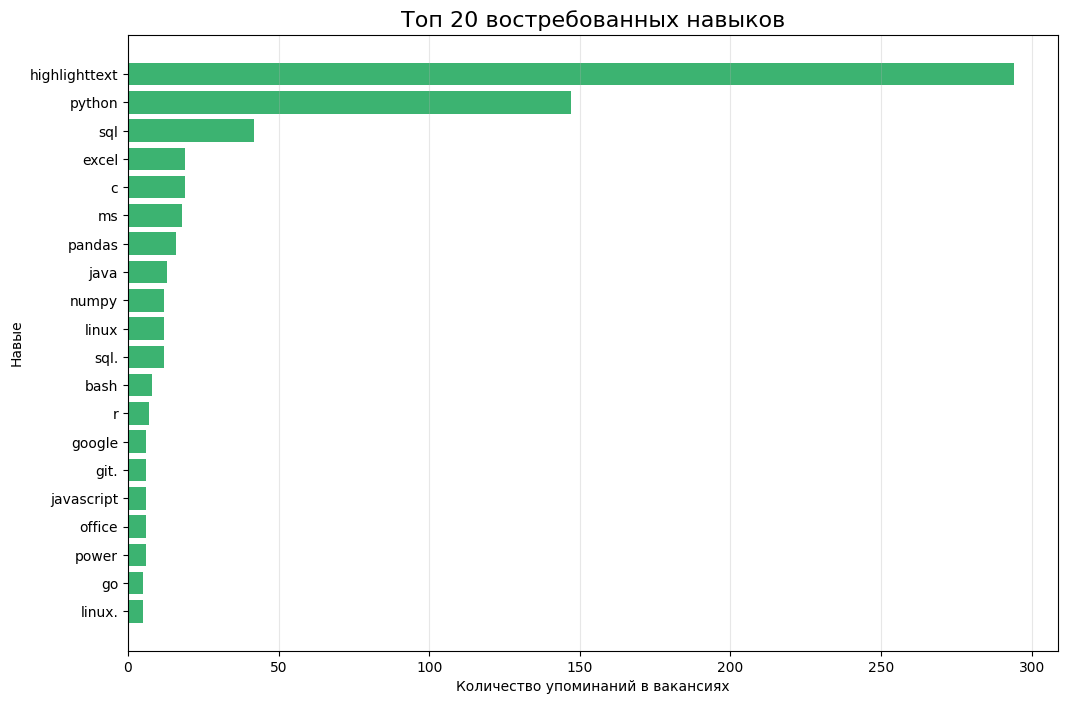

In [19]:
import re
from collections import Counter

all_text = " ".join(df['requirement'].dropna().astype(str))

words = re.findall(r'[a-zA-Z]+[a-zA-Z0-9\-\.]*', all_text)

words = [word.lower() for word in words]

stop_words = {
    'the', 'and', 'with', 'for', 'from', 'using', 'experience', 'knowledge', 
    'work', 'development', 'skills', 'good', 'strong', 'ability', 'will', 
    'team', 'plus', 'preferred', 'working', 'design', 'high', 'technical'
}

filtered_words = [w for w in words if w not in stop_words]

word_counts = Counter(filtered_words)

top_skills = dict(word_counts.most_common(20))

plt.figure(figsize=(12, 8))
labels = list(top_skills.keys())
values = list(top_skills.values())

plt.barh(labels, values, color='mediumseagreen')
plt.gca().invert_yaxis()

plt.title('Топ 20 востребованных навыков', fontsize=16)
plt.xlabel('Количество упоминаний в вакансиях')
plt.ylabel('Навые')
plt.grid(axis='x', alpha=0.3)
plt.show()